In [1]:
import pandas as pd
import numpy as np
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df = pd.read_csv(url, names=columns)
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [4]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------------- ------------------------- 2.9/8.2 MB 16.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.2 MB 12.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 10.1 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 8.1 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 7.3 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 6.1 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.6 MB 6.8 MB/s eta 0:00:06
   -- ------------------------------------- 2.4/36.6 MB 5.6 MB/s eta 0:00:07
   --- ------------------------------------ 3.1/36.6 MB 5.0 MB/s eta 0:00:07
   ---- ----------------------------------- 3.9/36.6 MB 4.9 MB/s eta 0:00:07
   ----- ------------

Performing EDA: A critical first step in any data analytics or data science workflow. It involves using statistical and visualization techniques to understand a dataset’s structure, detect anomalies, uncover patterns, and assess relationships between variables before applying modeling or predictive algorithms .

In [2]:
df.info()
df.isnull().sum() #check and sum the number of Null in each column
df["class"].value_counts()
for col in columns:
    print(col,df[col].unique())

<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB
buying <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
maint <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
doors <StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str
persons <StringArray>
['2', '4', 'more']
Length: 3, dtype: str
lug_boot <StringArray>
['small', 'med', 'big']
Length: 3, dtype: str
safety <StringArray>
['low', 'med', 'high']
Length: 3, dtype: str
class <StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str


Encoding and applying SCIKIT-LEARN
Models need numbers, not text, but every column in this dataset is text ("low", "med", "high", "vhigh", etc). This step converts each text column into numbers so the models can use it.

from sklearn.preprocessing import LabelEncoder imports the tool that converts text categories into numbers.

le_dict = {} creates an empty dictionary to store each column's encoder for later use, in case we need to convert numbers back to their original text later.

df_encoded = df.copy() makes a full copy of the dataframe so the edits happen on the copy, keeping the original df untouched.

for col in columns: loops through each column name one at a time: buying, maint, doors, persons, lug_boot, safety, class.

le = LabelEncoder() creates a fresh, empty encoder for that specific column. A new encoder is used per column because each column has different category values.

df_encoded[col] = le.fit_transform(df[col]) looks at the column's unique text values, assigns each one a number, and replaces the text with those numbers in df_encoded.

le_dict[col] = le saves that column's encoder into the dictionary, keyed by column name, so the mapping (e.g. "low" = 0) can be looked up or reversed later.

df_encoded.head() displays the first 5 rows to confirm the text values have been replaced with numbers.

In [5]:
from sklearn.preprocessing import LabelEncoder
le_dict = {}
df_encoded = df.copy()
for col in columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    le_dict[col] = le
df_encoded.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [7]:
# 4. Define X and y
X = df_encoded.drop(columns=["class"])
y = df_encoded["class"]

In [8]:
# 5. Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
# 6. Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# 7. Train two classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
log_preds = log_reg.predict(X_test_scaled)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
rf_preds = rf_clf.predict(X_test)

In [11]:
# 8. Evaluate — note average="weighted" since this is multi-class, not binary
for name, preds in [("Logistic Regression", log_preds), ("Random Forest", rf_preds)]:
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds, average="weighted"))
    print("Recall:", recall_score(y_test, preds, average="weighted"))
    print("F1:", f1_score(y_test, preds, average="weighted"))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))


Logistic Regression
Accuracy: 0.6878612716763006
Precision: 0.5753765983534769
Recall: 0.6878612716763006
F1: 0.6093356219066112
Confusion Matrix:
 [[  5   0  63   9]
 [  1   0  13   0]
 [ 11   0 231   0]
 [  3   0   8   2]]

Random Forest
Accuracy: 0.9826589595375722
Precision: 0.9826109865911683
Recall: 0.9826589595375722
F1: 0.982513776191318
Confusion Matrix:
 [[ 73   1   3   0]
 [  1  13   0   0]
 [  0   0 242   0]
 [  1   0   0  12]]


C:\Users\HARSH GOSAI\PycharmProjects\WelcomeScreen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
# 9. Cross-validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_clf, X, y, cv=5)
print("Cross-val scores:", cv_scores)
print("Average:", cv_scores.mean())

Cross-val scores: [0.74277457 0.75433526 0.83526012 0.85507246 0.88985507]
Average: 0.8154594956856831


In [13]:
# 10. Pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])
pipeline.fit(X_train, y_train)
pipeline_preds = pipeline.predict(X_test)
print("Pipeline accuracy:", accuracy_score(y_test, pipeline_preds))

Pipeline accuracy: 0.6878612716763006


In [14]:
# 11. Feature importance
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

safety      0.277857
persons     0.223212
buying      0.183894
maint       0.158944
lug_boot    0.086729
doors       0.069363
dtype: float64


In [17]:
!pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


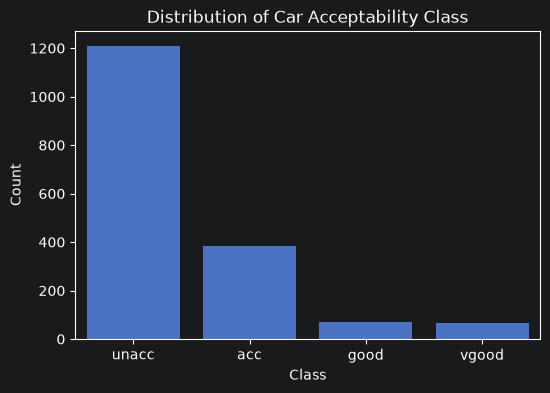

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Target class distribution — shows the class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x="class", data=df, order=df["class"].value_counts().index)
plt.title("Distribution of Car Acceptability Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

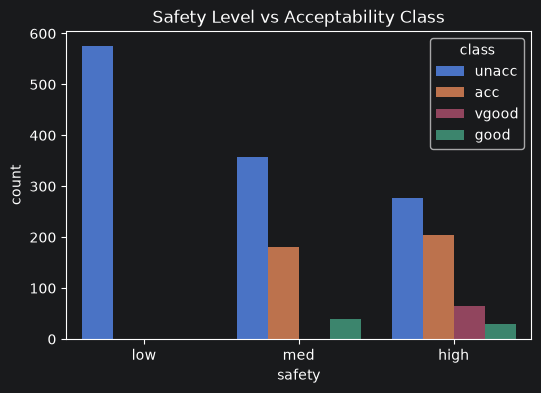

In [19]:
# 2. Safety vs class — a strong predictor, worth visualizing
plt.figure(figsize=(6,4))
sns.countplot(x="safety", hue="class", data=df)
plt.title("Safety Level vs Acceptability Class")
plt.show()

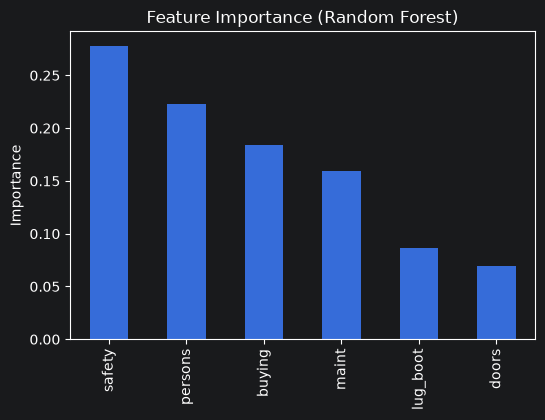

In [20]:
# 3. Feature importance bar chart (from your Random Forest)
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

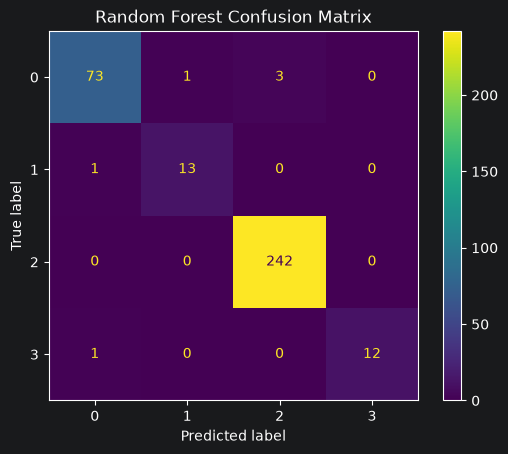

In [21]:
# 4. Confusion matrix, visualized instead of just printed
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf_preds)
plt.title("Random Forest Confusion Matrix")
plt.show()